# Finding multiple minima — the hopping family

**Hopping** runs a Markov chain *over minima*: from the current minimum,
perturb, locally minimize to a neighboring minimum, and accept or reject by
a Metropolis rule on the objective.

| method | rule | reference |
|---|---|---|
| `basinhopping` | perturb + local-minimize + Metropolis accept | Li & Scheraga, *PNAS* **84** (1987); Wales & Doye, *J. Phys. Chem. A* **101** (1997) |

A close cousin, **minima hopping** (Goedecker, *J. Chem. Phys.* **120**,
2004), replaces the random perturbation with short MD and a feedback
temperature. See `docs/src/find-minima.md`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pounce
print("pounce", pounce.__version__)

pounce 0.9.0


## The test landscape

Rastrigin again — the hop chain wandering its lattice of minima is easy to visualize.

/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_9031/2872884343.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


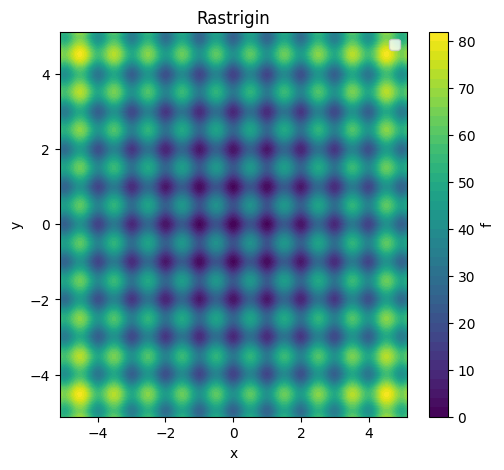

In [2]:
# Rastrigin: a lattice of local minima; single global minimum at the origin.
def fun(z):
    return 10*len(z) + sum(zi*zi - 10*np.cos(2*np.pi*zi) for zi in z)

def jac(z):
    return np.array([2*zi + 20*np.pi*np.sin(2*np.pi*zi) for zi in z])

def hess(z):
    return np.diag([2 + 40*np.pi**2*np.cos(2*np.pi*zi) for zi in z])

bounds = [(-5.12, 5.12)] * 2

def plot_landscape(minima=None, title="", chain=None):
    xs = np.linspace(-5.12, 5.12, 400)
    X, Y = np.meshgrid(xs, xs)
    Z = 20 + (X**2 - 10*np.cos(2*np.pi*X)) + (Y**2 - 10*np.cos(2*np.pi*Y))
    plt.figure(figsize=(5.6, 5))
    plt.contourf(X, Y, Z, levels=40, cmap="viridis"); plt.colorbar(label="f")
    if chain is not None and len(chain):
        C = np.array(chain)
        plt.plot(C[:, 0], C[:, 1], "-o", c="white", ms=4, lw=1, alpha=0.7,
                 label="hop chain")
    if minima is not None and len(minima):
        M = np.array(minima)
        plt.scatter(M[:, 0], M[:, 1], c="red", s=70, edgecolors="white",
                    zorder=5, label=f"{len(M)} minima")
    plt.legend(loc="upper right")
    plt.title(title); plt.xlabel("x"); plt.ylabel("y"); plt.show()

plot_landscape(title="Rastrigin")

## Basin-hopping

The chain is biased downhill by the Metropolis rule, so it reliably reaches the **global** minimum while collecting the distinct minima it visits.

  f=  0.00000  at (+0.0000, +0.0000)
  f=  0.99496  at (+0.0000, +0.9950)
  f=  0.99496  at (-0.9950, -0.0000)
  f=  1.98992  at (-0.9950, +0.9950)
  f=  4.97479  at (-0.9950, +1.9899)
  f=  4.97479  at (+1.9899, +0.9950)
  f=  8.95460  at (-2.9849, +0.0000)
  f=  9.94956  at (-2.9849, +0.9950)

status=target_reached  found=8  solves=12


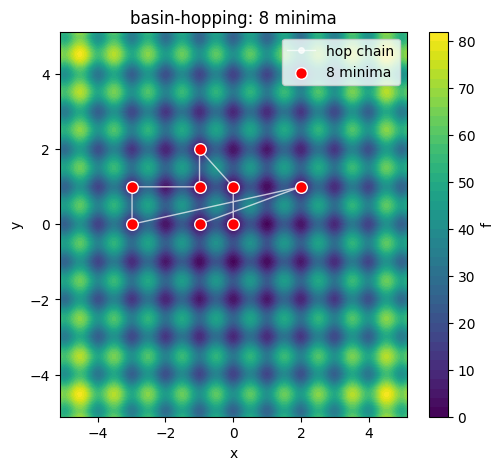

In [3]:
r = pounce.find_minima(fun, [0.3, 0.3], method="basinhopping", jac=jac,
                       hess=hess, bounds=bounds, n_minima=8, max_solves=200,
                       patience=60, dedup=1e-2, seed=1,
                       strategy_kw={"step": 0.7, "temperature": 2.0},
                       options={"print_level": 0, "tol": 1e-9})
for x, f in zip(r.minima, r.values):
    print(f"  f={f:9.5f}  at ({x[0]:+.4f}, {x[1]:+.4f})")
print(f"\nstatus={r.status}  found={len(r)}  solves={r.n_solves}")

# The sequence of minima the chain actually accepted, in visit order.
chain = [t["x"] for t in r.trace if t["accepted"]]
plot_landscape(r.minima, title=f"basin-hopping: {len(r)} minima", chain=chain)

## Choosing within the hopping family

* **`basinhopping`** — the chemistry/physics workhorse for the **global**
  minimum on rugged landscapes; tune `step` (perturbation size) and
  `temperature` (acceptance). It enumerates the minima it happens to visit,
  but is biased toward low ones rather than exhaustive.
* **minima hopping** (cousin) — adds history feedback to avoid revisiting;
  see the reference above.

Hopping needs no gradient of any repulsion term and is robust on noisy,
many-funnel landscapes. See `docs/src/find-minima.md` for when to prefer
hopping over repulsion or restart.